# ITBA - Machine Learning Engineering
### Trabajo Práctico Final
Tomás Pont Verges - DNI 30980439 - tomaspont@gmail.com

El objetivo de este trabajo es predecir el precio de venta de propiedades en Capital Federal, aplicando el ciclo completo de un proyecto de Machine Learning: desde la exploración de los datos hasta la evaluación de distintos modelos.

## Carga de data, librerías y funciones

In [166]:
### Librerías
import pandas as pd
import numpy as np
import geopandas as gpd

import re
import unicodedata
import requests
import gdown

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib.ticker import ScalarFormatter, AutoLocator, FuncFormatter

import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_error
from matplotlib.gridspec import GridSpec
from sklearn.compose import ColumnTransformer
from sklearn import linear_model

In [167]:
# pequeña función para printear un objeto sin truncar
def print_full(x):
    pd.set_option('display.max_rows', len(x))
    print(x)
    pd.reset_option('display.max_rows')

In [168]:
# Correr solo si no está descargado el archivo:

## descarga del dataset
## https://drive.google.com/file/d/1o2P0Mg5mZgMZysrPHC8GKmwIg_QTzzN7/view

!mkdir -p data
!gdown "https://drive.google.com/uc?id=1o2P0Mg5mZgMZysrPHC8GKmwIg_QTzzN7" -O data/properati.csv

Using cookies from /home/tepeve/.cache/gdown/cookies.txt
Downloading...
From (original): https://drive.google.com/uc?id=1o2P0Mg5mZgMZysrPHC8GKmwIg_QTzzN7
From (redirected): https://drive.google.com/uc?id=1o2P0Mg5mZgMZysrPHC8GKmwIg_QTzzN7&confirm=t&uuid=8a67dabd-20ba-4540-a8ee-b5b362d08052
To: /home/tepeve/itba/repo/properati/data/properati.csv
100%|███████████████████████████████████████| 904M/904M [00:22<00:00, 40.4MB/s]


In [124]:
# Instanciamos el dataset descargado en el objeto df
df = pd.read_csv('data/properati.csv')

# Exploración, Preprocesamiento y Transformación

## Data Cleaning

In [125]:
# Exploramos la forma del dataset
print("Tipo de dato: " + str(type(df)))
print(str(df.shape[1]) + ' columnas')
print(str(df.shape[0]) + ' filas')

Tipo de dato: <class 'pandas.DataFrame'>
25 columnas
992192 filas


In [126]:
# Exploramos el nombre de las columnas
df.columns 

Index(['id', 'ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon',
       'l1', 'l2', 'l3', 'l4', 'l5', 'l6', 'rooms', 'bedrooms', 'bathrooms',
       'surface_total', 'surface_covered', 'currency', 'price_period', 'title',
       'description', 'property_type', 'operation_type', 'price'],
      dtype='str')

In [127]:
# Chequeamos si hay filas duplicadas
dupl_df = df.duplicated()
any(dupl_df)


False

Vamos ahora a explorar columnas cuyo nombre no nos informan sobre su contenido. 

In [128]:
# exploramos el contenido de las columnas l1 a l6

for i in ["l1","l2","l3","l4","l5","l6"]:
    print(f"Value counts for column {i}:")
    print(df[i].value_counts())
    print()
    

Value counts for column l1:
l1
Argentina         973422
Uruguay            17929
Estados Unidos       783
Brasil                58
Name: count, dtype: int64

Value counts for column l2:
l2
Capital Federal                 249738
Buenos Aires Costa Atlántica    178712
Bs.As. G.B.A. Zona Norte        127510
Bs.As. G.B.A. Zona Sur          112975
Santa Fe                         93111
Bs.As. G.B.A. Zona Oeste         73172
Córdoba                          60877
Buenos Aires Interior            22280
Mendoza                          11558
Neuquén                          10642
Maldonado                        10101
Montevideo                        6318
Río Negro                         5507
Tucumán                           5425
Entre Ríos                        5113
Misiones                          4981
Salta                             3085
San Luis                          2101
Chaco                             1145
Corrientes                        1052
San Juan                       

Vemos que la columna "l1" = países; "l2" = regiones y/o provincias subnacionales; "l3" = departamentos y/o partidos; "l4" = localidades; "l5" = barrios. 

Vamos a renombrarlas con términos significativos (en inglés, ya que el resto de las columnas del dataset están en ese idioma):

In [129]:
df.rename(
    columns={
        "l1": "country_name",
        "l2": "state_name",
        "l3": "county_name",
        "l4": "city_name",
        "l5": "neighborhood_name",
    },
    inplace=True
)

### Recorte del dataset a nuestro universo de análisis

In [130]:
# Contamos la cantidad de avisos por tipo de operación

df.operation_type.value_counts()

operation_type
Venta                762318
Alquiler             199399
Alquiler temporal     30475
Name: count, dtype: int64

Vamos a dejar solo las propiedades en Venta. Tomamos esa decisión asumiendo que las propiedades en Alquiler y Alquiler Temporal deberían entrenarse por separado.

In [131]:
# Dejamos solo los avisos de tipo 'Venta'
print("Filas antes de filtrar por 'Venta': " + str(df.shape[0]))
df = df.loc[df['operation_type'] == 'Venta'].copy()
print("Filas después de filtrar por 'Venta': " + str(df.shape[0]))


Filas antes de filtrar por 'Venta': 992192
Filas después de filtrar por 'Venta': 762318


Ahora vamos a dejar solo las propiedades de Capital Federal.Pero antes, veamos la distribución a nivel Región / Provincia, del dataset original.

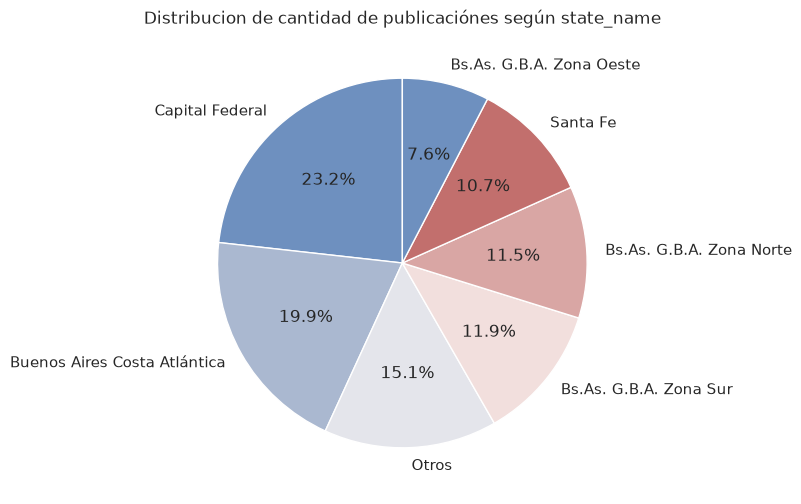

In [132]:
state_counts =  df['state_name'].value_counts()
# threshold de pequeñas categorias
threshold = 0.07 * len(df)
Categorias_chicas = state_counts[state_counts < threshold].index
s_state_name = df['state_name'].apply(lambda x: 'Otros' if x in Categorias_chicas else x)
plt.figure(figsize=(8, 6))
s_state_name.value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribucion de cantidad de publicaciónes según state_name')
plt.ylabel('')
plt.show()

In [133]:
# Dejamos solo los avisos de Capital Federal
print("Filas antes de filtrar por state_name: " + str(df.shape[0]))
df = df.loc[df['state_name'] == 'Capital Federal'].copy()
print("Filas después de filtrar por state_name: " + str(df.shape[0]))


Filas antes de filtrar por state_name: 762318
Filas después de filtrar por state_name: 177111


### Definición de data types

In [139]:
df.info()

<class 'pandas.DataFrame'>
Index: 177111 entries, 0 to 992191
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   id                 177111 non-null  int64         
 1   ad_type            177111 non-null  str           
 2   start_date         177111 non-null  datetime64[us]
 3   end_date           177111 non-null  datetime64[us]
 4   created_on         177111 non-null  datetime64[us]
 5   lat                152061 non-null  float64       
 6   lon                152147 non-null  float64       
 7   country_name       177111 non-null  str           
 8   state_name         177111 non-null  str           
 9   county_name        156677 non-null  str           
 10  city_name          5761 non-null    str           
 11  neighborhood_name  0 non-null       float64       
 12  l6                 0 non-null       float64       
 13  rooms              118878 non-null  float64       
 14  bedr

Por ahora vamos a ver convertir de strings a datetime las columnas temporales 'start_date', 'end_date' y 'created_on'.

In [138]:
# Columna de fechas
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])
df['created_on'] = pd.to_datetime(df['created_on'])

# Convertimos las coordenadas de latitud y longitud a geometría de puntos
df['geometry'] = gpd.points_from_xy(df['lon'], df['lat'])

### Normalización

#### Columnas string con texto

In [140]:
# Función custom con regex para normalizar texto
def normalize_text(x):
    if pd.isna(x):
        return x
    x = str(x).strip().lower()
    # quita tildes/acentos
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("ascii")
    # deja letras, numeros, espacio, guion y underscore
    x = re.sub(r"[^\w\s-]", "", x)
    # espacios/guiones -> underscore
    x = re.sub(r"[\s-]+", "_", x)
    # colapsa underscores repetidos
    x = re.sub(r"_+", "_", x).strip("_")
    return x

# 1) nombres de columnas
df.columns = [normalize_text(c) for c in df.columns]

# 2) columnas string a normalizar (ajusta exclusiones segun tu caso)
string_cols = df.select_dtypes(include=["object", "string"]).columns
exclude_cols = {"title", "description"}  # opcional: texto libre
cols_to_normalize = [c for c in string_cols if c not in exclude_cols]

for c in cols_to_normalize:
    df[c] = df[c].map(normalize_text)

#### Normalización de 'price'

Vamos a llevar todos los precios a una sóla divisa: el dólar estadounidense.

In [141]:
# Vemos los valores únicos de la columna 'currency' y su frecuencia
df.currency.value_counts()

currency
usd    169054
ars      1742
Name: count, dtype: int64

Vamos a eliminar los registros de divisas que no son dólares ni pesos argentinos.

In [142]:
df = df[df.currency.isin(['usd', 'ars'])]

Descargamos la cotización del dolar blue histórico

In [143]:
# Descargamos la cotización del dolar blue histórico del sitio Argentina Datos
# ver más en https://argentinadatos.com/docs/operations/get-cotizaciones-dolares-casa.html

url_blue =    "https://api.argentinadatos.com/v1/cotizaciones/dolares/blue"
response_blue = requests.get(url_blue)
json_blue = response_blue.json()

# la request devuelve un JSON con la estructura:
# [  {    "moneda": "string",    "casa": "string",    "fecha": "string",    "compra": 0,    "venta": 0  }]

# convertimos el JSON a un DataFrame de pandas y parseamos la columna 'fecha' a tipo datetime
df_blue = pd.DataFrame(json_blue)
df_blue['fecha'] = pd.to_datetime(df_blue['fecha'])

# filtramos las filas de df_blue que están fuera del rango de fechas de df
blue_mask_out = (df_blue['fecha'] < df.created_on.min()) | (df_blue['fecha'] > df.created_on.max())
df_blue = df_blue.loc[~blue_mask_out]
df_blue = df_blue.sort_values('fecha')
created_on_min = pd.to_datetime(df["created_on"], errors="coerce").min()
created_on_max = pd.to_datetime(df["created_on"], errors="coerce").max()

if pd.isna(created_on_min) or pd.isna(created_on_max):
    print("No hay rango de fechas válido en df['created_on']; se omite el filtro temporal de df_blue.")
else:
    blue_mask_out = (df_blue["fecha"] < created_on_min) | (df_blue["fecha"] > created_on_max)
    df_blue = df_blue.loc[~blue_mask_out].copy()
print("Rango de fechas de df_blue: {} to {}".format(df_blue['fecha'].min(), df_blue['fecha'].max()))

Rango de fechas de df_blue: 2019-07-04 00:00:00 to 2020-07-27 00:00:00


In [144]:
# hacemos un merge de df para obtener la cotización del dólar blue más cercana hacia atrás

df = pd.merge_asof(
    df.sort_values('created_on'), df_blue[['venta','fecha']].sort_values('fecha'), left_on='created_on', right_on='fecha', direction='backward')

df.rename(columns={'venta': 'blue_venta'}, inplace=True)


In [145]:
# mostramos las columnas relevantes para verificar el merge
df[['created_on', 'blue_venta','fecha']].sample(20)

,created_on,blue_venta,fecha
150594,2020-05-27,127,2020-05-27
32740,2019-10-10,62,2019-10-10
15680,2019-08-13,57,2019-08-13
144111,2020-05-13,129,2020-05-13
57246,2019-11-29,70,2019-11-29
138966,2020-04-27,117,2020-04-27
138401,2020-04-26,117,2020-04-26
167153,2020-07-15,127,2020-07-15
21010,2019-08-27,58,2019-08-27
64191,2019-12-18,75,2019-12-18


In [146]:
# Eliminamos la columna 'fecha' xq ya no es necesaria
df.drop(columns=['fecha'], inplace=True)

Antes de convertir los valores en pesos a dólares evaluamos la distribución de precios en pesos y en dólares con el objetivo de entender mejor la distribución y detectar posibles outliers o errores.

Para eso vamos a definir una heurística para detectar registros con precios en pesos inconsistentes. Vamos a tomar los avisos en ARS y calcular su precio implícito en USD dividiendo "price" por "blue_venta",  

Luego usando como referencia la distribución de los avisos que ya están correctamente publicados en USD, vamos a marcar como registros en pesos sospechosos aquellos avisos en ARS cuyo precio en USD una vez convertidos quedan por debajo del percentil 3 de los precios en USD. Como validación adicional, observamos si esos casos se concentran en montos redondos, lo que refuerza la hipótesis de una moneda mal definida.

Cantidad de sospechosos: 607


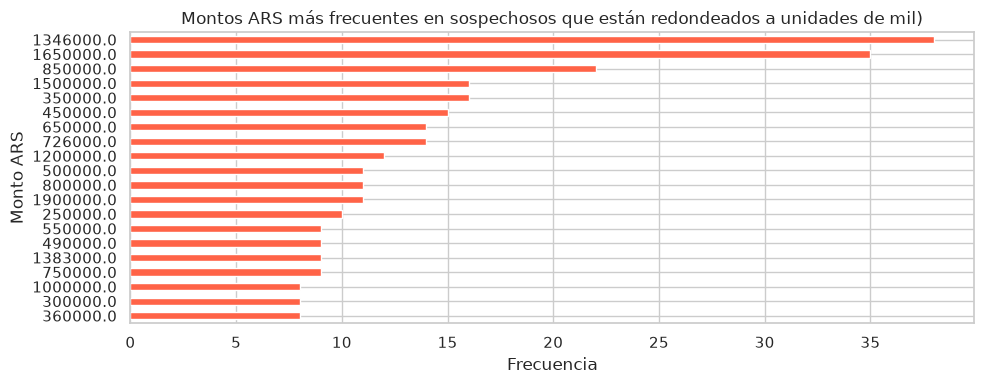

,created_on,price,blue_venta,price_usd_impl,property_type,state_name
132776,2020-04-13,100000.0,87,1149.425287,otro,capital_federal
4669,2019-07-15,216000.0,43,5023.255814,ph,capital_federal
5115,2019-07-17,216000.0,44,4909.090909,ph,capital_federal
589,2019-07-04,220000.0,43,5116.279070,departamento,capital_federal
590,2019-07-04,220000.0,43,5116.279070,departamento,capital_federal
67448,2019-12-27,229000.0,79,2898.734177,departamento,capital_federal
68022,2019-12-29,229000.0,78,2935.897436,departamento,capital_federal
26696,2019-09-13,230000.0,61,3770.491803,departamento,capital_federal
30831,2019-09-25,230000.0,62,3709.677419,local_comercial,capital_federal
70412,2020-01-05,230000.0,77,2987.012987,casa,capital_federal


In [147]:
# Separamos el dataset  de los datos por moneda 
ars = df[df["currency"].eq("ars")].copy()
usd = df[df["currency"].eq("usd")].copy()

# Precio implícito en USD para avisos ARS
ars["price_usd_impl"] = ars["price"] / ars["blue_venta"]

# Serie de precios USD limpia y numérica
usd_vals = pd.to_numeric(usd["price"], errors="coerce")
usd_vals = usd_vals.replace([np.inf, -np.inf], np.nan).dropna()

# Umbrales
usd_p03 = usd_vals.quantile(0.03)
p10_usd, p90_usd = usd_vals.quantile([0.10, 0.90])


# Registros sospechosos de posible moneda mal definida
sospechosos = ars[(ars["price_usd_impl"] < usd_p03)     # implícitamente muy baratos en USD
].copy()

print("Cantidad de sospechosos:", len(sospechosos))



# ¿Se concentran en números redondos?
plt.figure(figsize=(10, 4))
sospechosos["price"].round(-3).value_counts().head(20).sort_values().plot(kind="barh", color="tomato")
plt.title("Montos ARS más frecuentes en sospechosos que están redondeados a unidades de mil)")
plt.xlabel("Frecuencia")
plt.ylabel("Monto ARS")
plt.tight_layout()
plt.show()


display(
    sospechosos[["created_on", "price", "blue_venta", "price_usd_impl", "property_type", "state_name"]]
    .sort_values("price")
    .head(30)
)

% ARS implícito por debajo de P03 USD: 34.85%
% ARS implícito dentro del rango P10-P90 de USD real: 40.64%


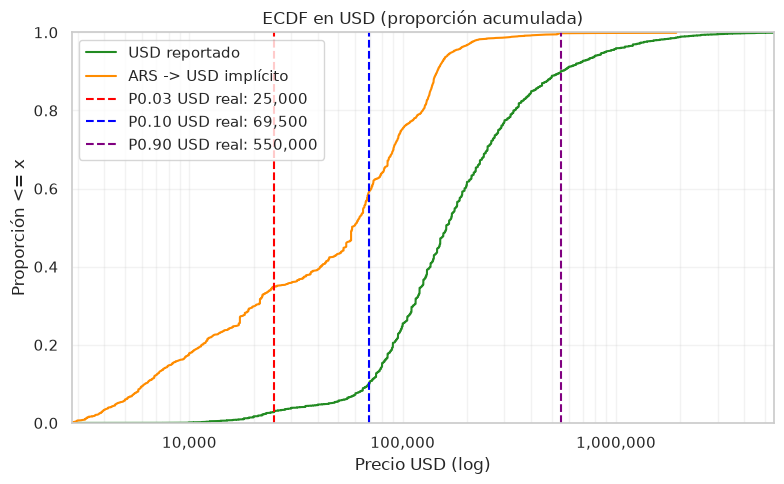

In [148]:
# Proporciones de ARS implícito bajo ciertos umbrales de USD real
share_below_p03 = (ars["price_usd_impl"] < usd_p03).mean()
print(f"% ARS implícito por debajo de P03 USD: {share_below_p03:.2%}")

share_in_core_usd = ((ars["price_usd_impl"] >= p10_usd) & (ars["price_usd_impl"] <= p90_usd)).mean()
print(f"% ARS implícito dentro del rango P10-P90 de USD real: {share_in_core_usd:.2%}")


# Curva acumulada para leer proporciones de avisos en pesos que convertidos 
# quedan bajo umbral de usd_p03

# Formateador simple
fmt = FuncFormatter(lambda x, _: f"{x:,.0f}")

# Rangos robustos para comparar visualmente
lo = min(usd["price"].quantile(0.001), ars["price_usd_impl"].quantile(0.001))
hi = max(usd["price"].quantile(0.999), ars["price_usd_impl"].quantile(0.999))

def ecdf(x):
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

xu, yu = ecdf(usd["price"])
xa, ya = ecdf(ars["price_usd_impl"])

plt.figure(figsize=(8, 5))
plt.plot(xu, yu, label="USD reportado", color="forestgreen")
plt.plot(xa, ya, label="ARS -> USD implícito", color="darkorange")
plt.axvline(usd_p03, color="red", linestyle="--", label=f"P0.03 USD real: {usd_p03:,.0f}")
plt.axvline(p10_usd, color="blue", linestyle="--", label=f"P0.10 USD real: {p10_usd:,.0f}")
plt.axvline(p90_usd, color="purple", linestyle="--", label=f"P0.90 USD real: {p90_usd:,.0f}")
plt.xscale("log")
plt.xlim(lo, hi)
plt.ylim(0, 1)
plt.title("ECDF en USD (proporción acumulada)")
plt.xlabel("Precio USD (log)")
plt.ylabel("Proporción <= x")
plt.gca().xaxis.set_major_formatter(fmt)
plt.grid(alpha=0.25, which="both")
plt.legend()
plt.tight_layout()
plt.show()

Esos resultados ayudan a detectar casos de posible mala catalogación en ARS. 3 de cada 10 avisos en ARS, convertidos a USD's, quedan en una zona extremadamente baja para precios de venta, Mientras que el 40 %  de los avisos en ARS una vez convertidos se comportan como precios de propiedades bien etiquetados.

Vamos a crear una columna de avisos en ARS "sospechosos". Estos registros van a definir su precio en dólares sin la conversión cambiaria. 

In [149]:
### Dummy de registros sospechosos (ARS mal catalogados)
df["is_sospechoso_ars"] = df.index.isin(sospechosos.index).astype(int)


In [150]:
# Unifica precio en USD sin perder columnas originales
df["price_usd"] = np.where(
    df["currency"].eq("usd") | (df["currency"].eq("ars") & df["is_sospechoso_ars"].eq(1)),
    df["price"],
    np.where(df["currency"].eq("ars"), df["price"] / df["blue_venta"], np.nan)
)

# vista rápida de control
df[["currency", "is_sospechoso_ars", "price", "price_usd"]].sample(50)

,currency,is_sospechoso_ars,price,price_usd
161349,usd,0,145000.0,145000.0
139678,usd,0,105918.0,105918.0
42784,usd,0,80000.0,80000.0
54393,usd,0,60000.0,60000.0
61730,usd,0,890000.0,890000.0
156761,usd,0,239000.0,239000.0
91088,usd,0,28000.0,28000.0
46700,usd,0,249400.0,249400.0
34274,usd,0,350000.0,350000.0
58817,usd,0,200000.0,200000.0


### Datos faltantes o mal ingresados

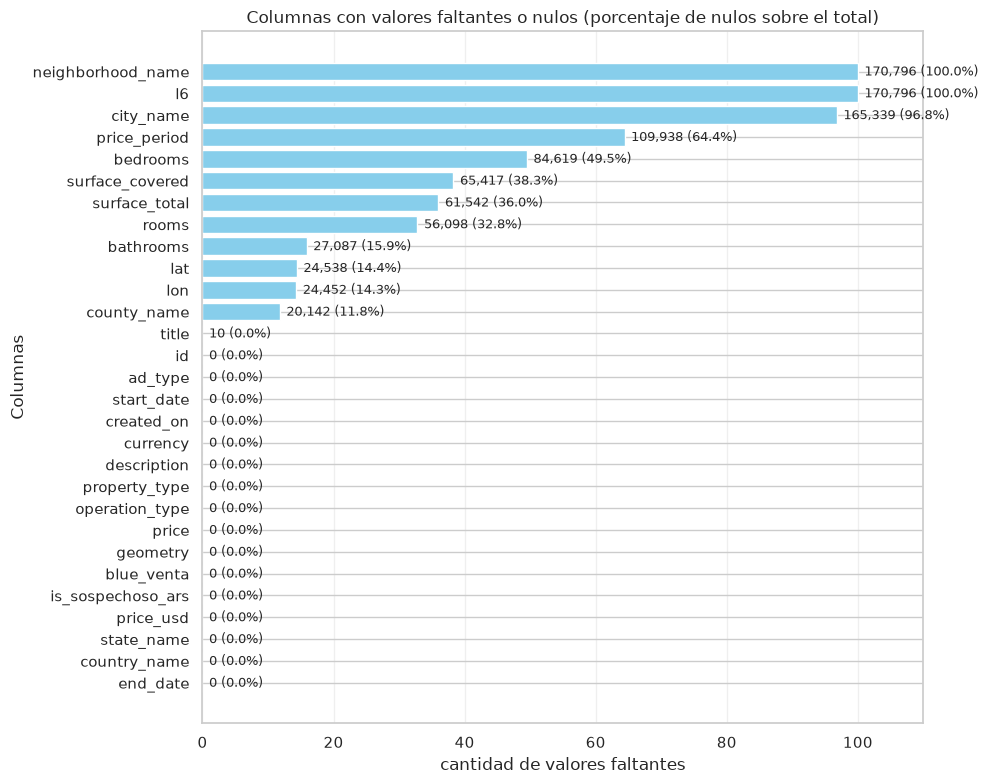

In [151]:
# evaluación de valores nulos en el dataset

columns_nanrows= df.isnull().sum()
columns_nanrows_percent = round(columns_nanrows/len(df)*100,1)
explore_nulls=pd.concat({'Rows sin data': columns_nanrows,'Porcentaje': columns_nanrows_percent},axis=1).sort_values(by='Rows sin data',ascending=False)
explore_nulls

explore_nulls_sorted = explore_nulls.sort_values(by='Rows sin data', ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(explore_nulls_sorted.index, explore_nulls_sorted['Porcentaje'], color='skyblue')
plt.xlabel('cantidad de valores faltantes')
plt.ylabel('Columnas')
plt.title('Columnas con valores faltantes o nulos (porcentaje de nulos sobre el total)')
plt.xticks(rotation=0)
plt.grid(axis='x', alpha=0.3)
plt.xlim(0, 110)  # espacio para que entren las etiquetas

for i, col in enumerate(explore_nulls_sorted.index):
    faltantes = int(columns_nanrows[col])
    porcentaje = columns_nanrows_percent[col]
    x = explore_nulls_sorted.loc[col, 'Porcentaje']
    plt.text(x + 1, i, f'{faltantes:,} ({porcentaje:.1f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

#### Fill nulls minando textos Title y Description

El minado busca reducir nulos en variables clave del inmueble (ambientes, superficies, baños y dormitorios) para mejorar la calidad del dataset antes de modelar. Se hace normalizando título y descripción, extrayendo señales numéricas con patrones simples y completando faltantes solo cuando hay evidencia textual consistente, manteniendo primero el valor original.



In [153]:
# Helpers reutilizables para minado de nulls y features booleanas desde title/description

NUMBER_WORDS = [
    ("un", "1"), ("una", "1"), ("dos", "2"), ("tres", "3"), ("cuatro", "4"),
    ("cinco", "5"), ("seis", "6"), ("siete", "7"), ("ocho", "8"), ("nueve", "9"), ("diez", "10")
]

PATTERNS = {
    "rooms": r"(\d{1,2})\s*(?:am\w*|do\w*|ha\w*)",
    "surface_total": r"(?:sup(?:erficie)?\s*(?:total|propia)?\s*[:\-]?\s*)(\d{2,4})\s*(?:m2|mt2|mts2|mts|m)\b",
    "surface_covered": r"(?:sup(?:erficie)?\s*(?:cub(?:ierta|iertos)?|cub)\s*[:\-]?\s*)(\d{2,4})\s*(?:m2|mt2|mts2|mts|m)\b",
    "surface_generic": r"\b(\d{2,4})\s*(?:m2|mt2|mts2|mts|m)\b",
    "bathrooms": r"\b(\d{1,2})\s*(?:banos?|baños?|toilettes?|sanitarios?)\b",
    "bedrooms": r"\b(\d{1,2})\s*(?:dorm(?:itorios?)?|hab(?:itaciones?)?|piezas?)\b",
}

def normalize_text_for_mining(series, number_words):
    out = series.fillna("").astype(str).str.lower()
    out = out.str.replace("m²", "m2", regex=False)
    for old, new in number_words:
        out = out.str.replace(old, new, regex=False)
    return out

def extract_num(series, pattern):
    return pd.to_numeric(series.str.extract(pattern, expand=False), errors="coerce")

def fill_from_candidates(base_series, candidates):
    out = pd.to_numeric(base_series, errors="coerce")
    for c in candidates:
        if isinstance(c, np.ndarray):
            c = pd.Series(c, index=out.index)
        out = out.fillna(c)
    return out

def print_nulls(label, series):
    print(f"nulls en {label}: {int(series.isna().sum())}")

In [154]:
# Pipeline unificado de minado + booleans

# 1) Texto base
df["title_mining"] = normalize_text_for_mining(df["title"], NUMBER_WORDS)
df["description_mining"] = normalize_text_for_mining(df["description"], NUMBER_WORDS)
df["text_mining"] = df["title_mining"] + " " + df["description_mining"]

# 2) Booleans de señales textuales
df["bool_mono_title"] = df["title_mining"].str.contains("monoamb", case=False, na=False).astype(int)
df["bool_mono_descr"] = df["description_mining"].str.contains("monoamb", case=False, na=False).astype(int)
df["bool_rooms_token_title"] = df["title_mining"].str.contains(PATTERNS["rooms"], regex=True, na=False).astype(int)
df["bool_rooms_token_descr"] = df["description_mining"].str.contains(PATTERNS["rooms"], regex=True, na=False).astype(int)
df["bool_surface_token"] = df["text_mining"].str.contains(PATTERNS["surface_generic"], regex=True, na=False).astype(int)
df["bool_bath_token"] = df["text_mining"].str.contains(PATTERNS["bathrooms"], regex=True, na=False).astype(int)
df["bool_bed_token"] = df["text_mining"].str.contains(PATTERNS["bedrooms"], regex=True, na=False).astype(int)

# 3) Rooms
print_nulls("rooms original", df["rooms"])
rooms_from_title = extract_num(df["title_mining"], PATTERNS["rooms"])
rooms_from_descr = extract_num(df["description_mining"], PATTERNS["rooms"])
mono_title = np.where(df["bool_mono_title"].eq(1), 1, np.nan)
mono_descr = np.where(df["bool_mono_descr"].eq(1), 1, np.nan)

df["rooms_clean"] = fill_from_candidates(
    df["rooms"],
    [rooms_from_title, mono_title, rooms_from_descr, mono_descr]
)
print_nulls("rooms_clean", df["rooms_clean"])

# 4) Superficies
print_nulls("surface_total original", df["surface_total"])
print_nulls("surface_covered original", df["surface_covered"])

surf_total_from_text = extract_num(df["text_mining"], PATTERNS["surface_total"])
surf_cov_from_text = extract_num(df["text_mining"], PATTERNS["surface_covered"])
surf_any_from_text = extract_num(df["text_mining"], PATTERNS["surface_generic"])

df["surface_total_clean"] = fill_from_candidates(
    df["surface_total"],
    [surf_total_from_text, surf_any_from_text]
)
df["surface_covered_clean"] = fill_from_candidates(
    df["surface_covered"],
    [surf_cov_from_text]
)

# Completar faltantes cruzados
df["surface_total_clean"] = df["surface_total_clean"].fillna(df["surface_covered_clean"])
df["surface_covered_clean"] = df["surface_covered_clean"].fillna(df["surface_total_clean"])

# Si covered > total, swap
mask_swap = (
    df["surface_covered_clean"].notna()
    & df["surface_total_clean"].notna()
    & (df["surface_covered_clean"] > df["surface_total_clean"])
)
a = df.loc[mask_swap, "surface_total_clean"].copy()
b = df.loc[mask_swap, "surface_covered_clean"].copy()
df.loc[mask_swap, "surface_total_clean"] = b
df.loc[mask_swap, "surface_covered_clean"] = a

print_nulls("surface_total_clean", df["surface_total_clean"])
print_nulls("surface_covered_clean", df["surface_covered_clean"])

# 5) Bathrooms y bedrooms
print_nulls("bathrooms original", df["bathrooms"])
print_nulls("bedrooms original", df["bedrooms"])

bath_from_text = extract_num(df["text_mining"], PATTERNS["bathrooms"])
bed_from_text = extract_num(df["text_mining"], PATTERNS["bedrooms"])

df["bathrooms_clean"] = fill_from_candidates(df["bathrooms"], [bath_from_text])
df["bedrooms_clean"] = fill_from_candidates(df["bedrooms"], [bed_from_text])

print_nulls("bathrooms_clean", df["bathrooms_clean"])
print_nulls("bedrooms_clean", df["bedrooms_clean"])

# 6) Tabla de control de nulls
pairs = [
    ("rooms", "rooms_clean"),
    ("surface_total", "surface_total_clean"),
    ("surface_covered", "surface_covered_clean"),
    ("bathrooms", "bathrooms_clean"),
    ("bedrooms", "bedrooms_clean"),
]

compare = pd.DataFrame({
    "variable": [orig for orig, _ in pairs],
    "n_orig": [df[orig].isna().sum() for orig, _ in pairs],
    "n_clean": [df[clean].isna().sum() for _, clean in pairs],
})
compare["pct_orig"] = (compare["n_orig"] / len(df) * 100).round(2)
compare["pct_clean"] = (compare["n_clean"] / len(df) * 100).round(2)
display(compare)

# 7) Resumen de booleans
vars_bools = df[
    [
        "bool_mono_title",
        "bool_mono_descr",
        "bool_rooms_token_title",
        "bool_rooms_token_descr",
        "bool_surface_token",
        "bool_bath_token",
        "bool_bed_token",
    ]
].copy()

vars_bools_long = vars_bools.melt(var_name="feature_bool", value_name="value")
display(vars_bools.mean().sort_values(ascending=False).rename("share_1"))

/tmp/ipykernel_169374/1829290861.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["bool_rooms_token_title"] = df["title_mining"].str.contains(PATTERNS["rooms"], regex=True, na=False).astype(int)
/tmp/ipykernel_169374/1829290861.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["bool_rooms_token_descr"] = df["description_mining"].str.contains(PATTERNS["rooms"], regex=True, na=False).astype(int)
/tmp/ipykernel_169374/1829290861.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["bool_surface_token"] = df["text_mining"].str.contains(PATTERNS["surface_generic"], regex=True, na=False).astype(int)
/tmp/ipykernel_169374/1829290861.py:14: UserWarning: This pattern is interpreted as a regular expression, and has ma

nulls en rooms original: 56098
nulls en rooms_clean: 19456
nulls en surface_total original: 61542
nulls en surface_covered original: 65417
nulls en surface_total_clean: 40532
nulls en surface_covered_clean: 40532
nulls en bathrooms original: 27087
nulls en bedrooms original: 84619
nulls en bathrooms_clean: 24847
nulls en bedrooms_clean: 63516


,variable,n_orig,n_clean,pct_orig,pct_clean
0,rooms,56098,19456,32.85,11.39
1,surface_total,61542,40532,36.03,23.73
2,surface_covered,65417,40532,38.30,23.73
3,bathrooms,27087,24847,15.86,14.55
4,bedrooms,84619,63516,49.54,37.19


bool_rooms_token_descr    0.710784
bool_rooms_token_title    0.455994
bool_surface_token        0.378516
bool_bed_token            0.303151
bool_bath_token           0.167270
bool_mono_descr           0.082953
bool_mono_title           0.039714
Name: share_1, dtype: float64

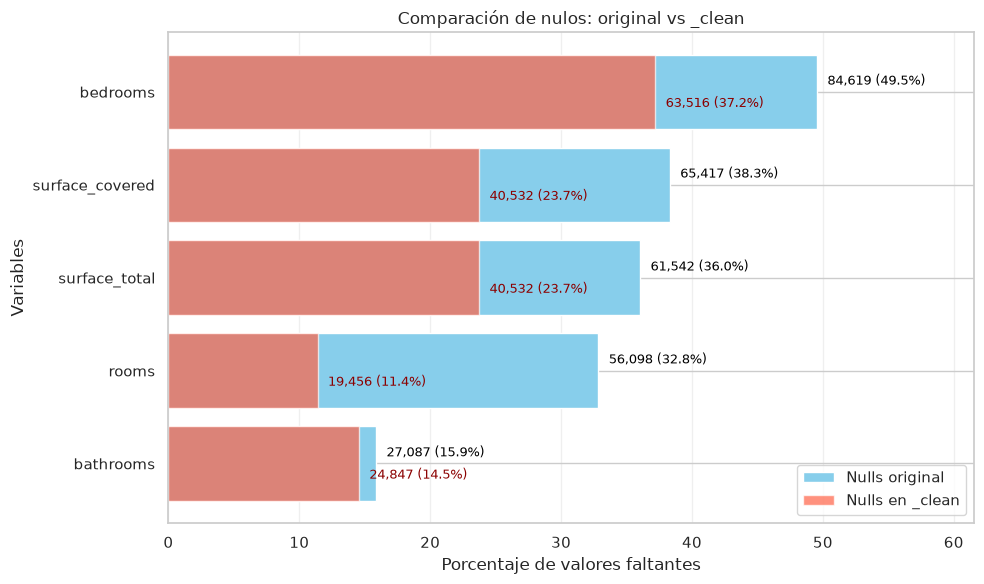

In [155]:
# evaluación de nulos solo para variables tratadas (original vs _clean)

pairs = [
    ("rooms", "rooms_clean"),
    ("surface_total", "surface_total_clean"),
    ("surface_covered", "surface_covered_clean"),
    ("bathrooms", "bathrooms_clean"),
    ("bedrooms", "bedrooms_clean"),
]

# Validación de columnas requeridas
required_cols = [c for pair in pairs for c in pair]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Faltan columnas en df: {missing_cols}")

n = len(df)
if n == 0:
    raise ValueError("df está vacío, no se puede graficar.")

# Tabla comparativa
compare = pd.DataFrame({
    "variable": [orig for orig, _ in pairs],
    "n_orig": [df[orig].isna().sum() for orig, _ in pairs],
    "n_clean": [df[clean].isna().sum() for _, clean in pairs],
})
compare["pct_orig"] = compare["n_orig"] / n * 100
compare["pct_clean"] = compare["n_clean"] / n * 100
compare = compare.sort_values("n_orig", ascending=True).set_index("variable")

# Si querés conservar estos objetos para celdas siguientes
explore_nulls = compare[["n_orig", "pct_orig", "n_clean", "pct_clean"]].rename(
    columns={
        "n_orig": "Rows sin data (orig)",
        "pct_orig": "Porcentaje (orig)",
        "n_clean": "Rows sin data (_clean)",
        "pct_clean": "Porcentaje (_clean)",
    }
)
explore_nulls_sorted = explore_nulls.copy()

# Gráfico
plt.figure(figsize=(10, 6))
y = np.arange(len(compare))

# Barra base: nulos originales
plt.barh(y, compare["pct_orig"], color="skyblue", label="Nulls original")
# Barra superpuesta: nulos en _clean
plt.barh(y, compare["pct_clean"], color="tomato", alpha=0.7, label="Nulls en _clean")

plt.yticks(y, compare.index)
plt.xlabel("Porcentaje de valores faltantes")
plt.ylabel("Variables")
plt.title("Comparación de nulos: original vs _clean")
plt.grid(axis="x", alpha=0.3)

# Anotaciones (original y clean)
for yi, var in enumerate(compare.index):
    # original
    plt.text(
        compare.loc[var, "pct_orig"] + 0.8,
        yi + 0.12,
        f'{int(compare.loc[var, "n_orig"]):,} ({compare.loc[var, "pct_orig"]:.1f}%)',
        va="center",
        fontsize=9,
        color="black",
    )
    # clean
    plt.text(
        compare.loc[var, "pct_clean"] + 0.8,
        yi - 0.12,
        f'{int(compare.loc[var, "n_clean"]):,} ({compare.loc[var, "pct_clean"]:.1f}%)',
        va="center",
        fontsize=9,
        color="darkred",
    )

xmax = max(compare["pct_orig"].max(), compare["pct_clean"].max())
plt.xlim(0, xmax + 12)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [156]:
# Filtrado de registros según columnas clave ya tratadas (_clean)
cols_obligatorias = ["surface_covered_clean", "surface_total_clean", "rooms_clean"]

filas_antes = len(df)

# Validamos  si tiene al menos un dato en esas columnas
mask_validas = df[cols_obligatorias].notna().any(axis=1)

filas_invalidas = df.loc[~mask_validas].copy()
filas_validas = df.loc[mask_validas].copy()

print(f"Filas antes: {filas_antes:,}")
print(f"Filas después: {len(filas_validas):,}")
print(f"Filas eliminadas: {filas_antes - len(filas_validas):,}")

df = filas_validas.copy()

Filas antes: 170,796
Filas después: 164,370
Filas eliminadas: 6,426


#### Columnas a descartar o crear

#### Tratamiento de Outliers

Vamos a revisar la consitencia temporal de las variables temporales del dataset. 

In [124]:
print("Rango de fechas de created_on: {} to {}".format(df.start_date.min(), df.start_date.max()))

print("Rango de fechas de created_on: {} to {}".format(df.created_on.min(), df.created_on.max()))

print("Rango de fechas de end_date: {} to {}".format(df.end_date.min(), df.end_date.max()))


Rango de fechas de created_on: 2019-07-04 00:00:00 to 2020-07-27 00:00:00
Rango de fechas de created_on: 2019-07-04 00:00:00 to 2020-07-27 00:00:00
Rango de fechas de end_date: 2019-07-05 00:00:00 to 9999-12-31 00:00:00


En la columna 'end_date', "9999-12-31" como valor de fecha claramente es un registro inválido, vamos a evaluar cuántos avisos contienen fechas de cierre no válidos, buscando valores de cierre que estén fuera de un rango de fechas (min de created_on y una fecha actual).

In [125]:
# diagnóstico de la serie temporal de avisos cerrados por fecha (end_date)

# outliers de fecha
end_date_mask_out = (df.end_date < pd.Timestamp("2019-01-01")) | (df.end_date > pd.Timestamp("2026-09-30"))
print("Cantidad de registros en 'end_date' con fechas fuera del rango:", end_date_mask_out.sum())

Cantidad de registros en 'end_date' con fechas fuera del rango: 157968


In [64]:
# Vamos a eliminar los registros con fechas de cierre fuera del rango
df = df.loc[~end_date_mask_out] 

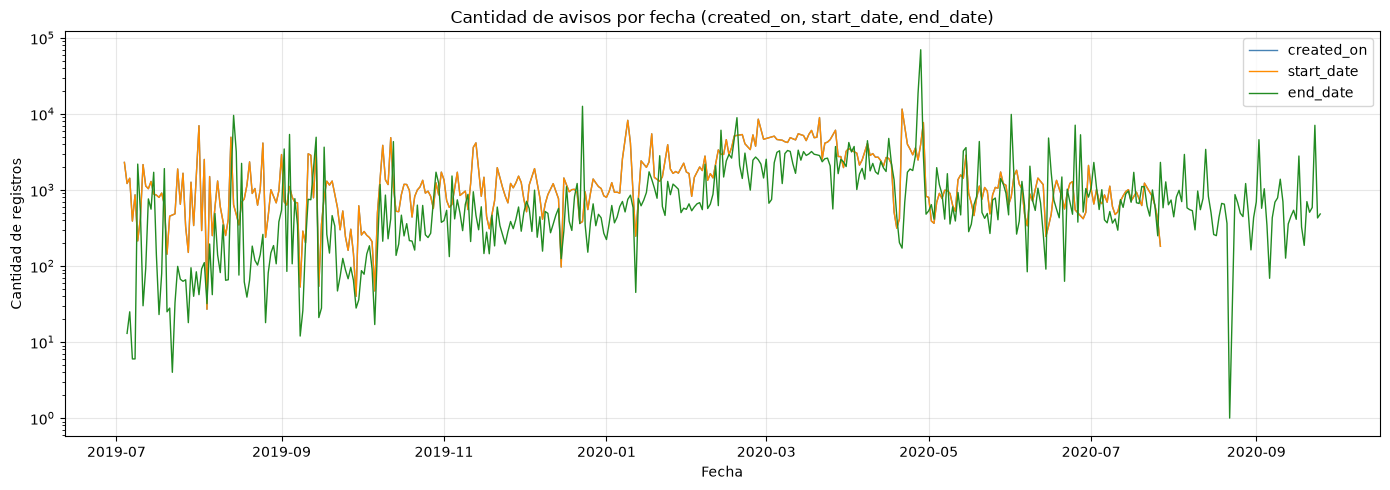

In [68]:


# Serie temporal: cantidad de avisos por fecha (created_on, start_date, end_date)
created_on_dt = pd.to_datetime(df["created_on"], errors="coerce")
start_date_dt = pd.to_datetime(df["start_date"], errors="coerce")
end_date_dt = pd.to_datetime(df["end_date"], errors="coerce")

avisos_created_on = created_on_dt.value_counts().sort_index()
avisos_start_date = start_date_dt.value_counts().sort_index()
avisos_end_date = end_date_dt.value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.plot(avisos_created_on.index, avisos_created_on.values, color="steelblue", linewidth=1, label="created_on")
plt.plot(avisos_start_date.index, avisos_start_date.values, color="darkorange", linewidth=1, label="start_date")
plt.plot(avisos_end_date.index, avisos_end_date.values, color="forestgreen", linewidth=1, label="end_date")
plt.title("Cantidad de avisos por fecha (created_on, start_date, end_date)")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de registros")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

En esta sección deberíamos de resolver los ouliers de price, pero vamos a tomar un rodeo: Vamos a recortar los outliers de price a través de una variable subrogada: el valor del metro cuadrado, que vamos a crear a continuación. 

##### Creación de la columna price_per_m2

Antes de crear la variable vamos a distinguir filas que podrían tener errores de registro,  filtrando observaciones con precios o superficies no válidas. 

In [179]:
# Objetivo: separar errores técnicos de outliers reales de mercado

df_diag = df.copy()

# Cast robusto a numérico (evita strings, inf, etc.)
df_diag["price_usd_num"] = pd.to_numeric(df_diag["price_usd"], errors="coerce")
df_diag["surface_total_num"] = pd.to_numeric(df_diag["surface_total_clean"], errors="coerce")

# Reglas de validez física mínima
mask_price_invalid = (~np.isfinite(df_diag["price_usd_num"])) | (df_diag["price_usd_num"] <= 0)
mask_surface_invalid = (~np.isfinite(df_diag["surface_total_num"])) | (df_diag["surface_total_num"] <= 0)

# Flag de plausibilidad (no elimina; solo diagnóstico)
mask_surface_implausible = (df_diag["surface_total_num"] < 10) | (df_diag["surface_total_num"] > 10000)

df_diag["flag_price_invalid"] = mask_price_invalid.astype(int)
df_diag["flag_surface_invalid"] = mask_surface_invalid.astype(int)
df_diag["flag_surface_implausible"] = mask_surface_implausible.astype(int)
df_diag["flag_invalid_physical"] = (mask_price_invalid | mask_surface_invalid).astype(int)

resumen = pd.DataFrame({
    "n": [
        len(df_diag),
        df_diag["flag_price_invalid"].sum(),
        df_diag["flag_surface_invalid"].sum(),
        df_diag["flag_surface_implausible"].sum(),
        df_diag["flag_invalid_physical"].sum()
    ]
}, index=[
    "Total registros",
    "price_usd inválido (NaN, inf, <=0)",
    "surface_total inválido (NaN, inf, <=0)",
    "surface_total implausible (<10 o >10000)",
    "inválidos físicos (price o surface)"
])

resumen["pct"] = (100 * resumen["n"] / len(df_diag)).round(2)
display(resumen)

# Base válida para outliers
df_work = df_diag.loc[df_diag["flag_invalid_physical"].eq(0)].copy()
print("Filas para modelado de outliers que pasaron la heúristica de validez:", len(df_work))

,n,pct
Total registros,164370,100.00
"price_usd inválido (NaN, inf, <=0)",0,0.00
"surface_total inválido (NaN, inf, <=0)",34342,20.89
surface_total implausible (<10 o >10000),642,0.39
inválidos físicos (price o surface),34342,20.89


Filas para modelado tras validez física: 130028


In [180]:
##### Creación de la columna price_per_m2
df_work["price_usd_per_m2"] = df_work["price_usd"] / df_work["surface_total"].replace(0, np.nan)



Luego trabajamos en escala logarítmica para estabilizar la distribución y se combinaron tres criterios de detección: IQR global, puntuaciones z-score de la desviación absoluta mediana (MAD) y umbrales extremos (percentiles 1 y 99) segmentados por tipo de propiedad. 

En lugar de eliminar masivamente observaciones, se construyó un score de consenso y se aplicó winsorización o transformación sobre los extremos, preservando la mayor cantidad de información posible y reduciendo el impacto de valores atípicos en el entrenamiento de modelos.

In [183]:
# =========================
# 2) Detección global en escala log
# =========================
df_work["log_ppm2"] = np.log(df_work["price_usd_per_m2"])

# IQR
q1 = df_work["log_ppm2"].quantile(0.25)
q3 = df_work["log_ppm2"].quantile(0.75)
iqr = q3 - q1
li_15, ls_15 = q1 - 1.5 * iqr, q3 + 1.5 * iqr
li_30, ls_30 = q1 - 3.0 * iqr, q3 + 3.0 * iqr

# Robust Z-score (MAD)
median = df_work["log_ppm2"].median()
mad = np.median(np.abs(df_work["log_ppm2"] - median))
if mad == 0:
    df_work["robust_z"] = 0.0
else:
    df_work["robust_z"] = 0.6745 * (df_work["log_ppm2"] - median) / mad

df_work["flag_iqr_15"] = ((df_work["log_ppm2"] < li_15) | (df_work["log_ppm2"] > ls_15)).astype(int)
df_work["flag_iqr_30"] = ((df_work["log_ppm2"] < li_30) | (df_work["log_ppm2"] > ls_30)).astype(int)
df_work["flag_rz_35"] = (df_work["robust_z"].abs() > 3.5).astype(int)

print("Outliers IQR 1.5:", round(df_work["flag_iqr_15"].mean() * 100, 2), "%")
print("Outliers IQR 3.0:", round(df_work["flag_iqr_30"].mean() * 100, 2), "%")
print("Outliers Robust Z > 3.5:", round(df_work["flag_rz_35"].mean() * 100, 2), "%")

Outliers IQR 1.5: 4.39 %
Outliers IQR 3.0: 0.81 %
Outliers Robust Z > 3.5: 0.0 %


In [184]:
# =========================
# 3) Detección segmentada por property_type (P01-P99)
# =========================
min_n = 80

if "property_type" in df_work.columns:
    grp_n = df_work.groupby("property_type")["log_ppm2"].transform("size")
    q01_grp = df_work.groupby("property_type")["log_ppm2"].transform(lambda s: s.quantile(0.01))
    q99_grp = df_work.groupby("property_type")["log_ppm2"].transform(lambda s: s.quantile(0.99))

    q01_glob = df_work["log_ppm2"].quantile(0.01)
    q99_glob = df_work["log_ppm2"].quantile(0.99)

    low = np.where(grp_n >= min_n, q01_grp, q01_glob)
    high = np.where(grp_n >= min_n, q99_grp, q99_glob)

    df_work["flag_grp_p01_p99"] = ((df_work["log_ppm2"] < low) | (df_work["log_ppm2"] > high)).astype(int)
else:
    low = np.repeat(df_work["log_ppm2"].quantile(0.01), len(df_work))
    high = np.repeat(df_work["log_ppm2"].quantile(0.99), len(df_work))
    df_work["flag_grp_p01_p99"] = ((df_work["log_ppm2"] < low) | (df_work["log_ppm2"] > high)).astype(int)

print("Outliers segmentados P01-P99:", round(df_work["flag_grp_p01_p99"].mean() * 100, 2), "%")

Outliers segmentados P01-P99: 1.65 %


In [185]:
# =========================
# 4) Score combinado + tratamiento (winsorización)
# =========================
df_work["outlier_score"] = (
    df_work["flag_iqr_15"] +
    df_work["flag_rz_35"] +
    df_work["flag_grp_p01_p99"]
)

# Winsorización jerárquica en log(price_usd_per_m2)
df_work["log_ppm2_cap"] = df_work["log_ppm2"].clip(low, high)
df_work["price_usd_per_m2_cap"] = np.exp(df_work["log_ppm2_cap"])

# Versiones finales para modelado (sin borrar la señal original)
df_work["price_usd_cap"] = df_work["price_usd_per_m2_cap"] * df_work["surface_total_num"]

# Resumen rápido
res = pd.DataFrame({
    "muestra": [len(df_work)],
    "score>=1": [(df_work["outlier_score"] >= 1).sum()],
    "score>=2": [(df_work["outlier_score"] >= 2).sum()],
    "score=3": [(df_work["outlier_score"] == 3).sum()]
})
display(res)

,muestra,score>=1,score>=2,score=3
0,130028,6181,1679,0


In [186]:
# 1) Asegurar consistencia del cálculo en df_work
# (usar la superficie validada, no la original)
df_work["price_usd_per_m2"] = df_work["price_usd_num"] / df_work["surface_total_num"]
df_work = df_work.loc[np.isfinite(df_work["price_usd_per_m2"]) & (df_work["price_usd_per_m2"] > 0)].copy()

# 2) Volcar resultados de outliers a df por índice
cols_out = [
    "price_usd_per_m2",
    "log_ppm2",
    "outlier_score",
    "price_usd_per_m2_cap",
    "price_usd_cap"
]

for c in cols_out:
    df[c] = np.nan

df.loc[df_work.index, cols_out] = df_work[cols_out]

# 3) Mantener target original + target cappeado
# Opción recomendada: no pisar price_usd
df["price_usd_original"] = df["price_usd"]

# Si querés que el target operativo sea el cappeado, descomentá:
# df["price_usd"] = d
# f["price_usd_cap"].where(df["price_usd_cap"].notna(), df["price_usd"])

print("Filas con target cappeado disponible:", df["price_usd_cap"].notna().sum())
print("Filas totales en df:", len(df))

Filas con target cappeado disponible: 109244
Filas totales en df: 164370


In [188]:
# --- Materializar impacto de outliers sobre target price_usd en df ---

# 1) Conservar original
df["price_usd_original"] = df["price_usd"]

# 2) Crear versión tratada (arranca igual al original)
df["price_usd_treated"] = df["price_usd_original"]

# 3) Elegir política de aplicación
# Recomendación: aplicar solo a outliers fuertes (score >= 2)
mask_apply = df["price_usd_cap"].notna() & (df["outlier_score"] >= 2)

# Si querés tratar también outliers leves, usar >= 1
# mask_apply = df["price_usd_cap"].notna() & (df["outlier_score"] >= 1)

# 4) Reemplazar target en esas filas con la versión cappeada
df.loc[mask_apply, "price_usd_treated"] = df.loc[mask_apply, "price_usd_cap"]

# 5) Definir target final para modelado (sin perder trazabilidad)
df["price_usd_target"] = df["price_usd_treated"]

print("Filas totales:", len(df))
print("Filas con price_usd_cap disponible:", int(df["price_usd_cap"].notna().sum()))
print("Filas efectivamente ajustadas en target:", int(mask_apply.sum()))
print("MAE cambio medio absoluto en target:",
      (df.loc[mask_apply, "price_usd_target"] - df.loc[mask_apply, "price_usd_original"]).abs().mean())

Filas totales: 164370
Filas con price_usd_cap disponible: 109244
Filas efectivamente ajustadas en target: 1679
MAE cambio medio absoluto en target: 1295056.5472653902


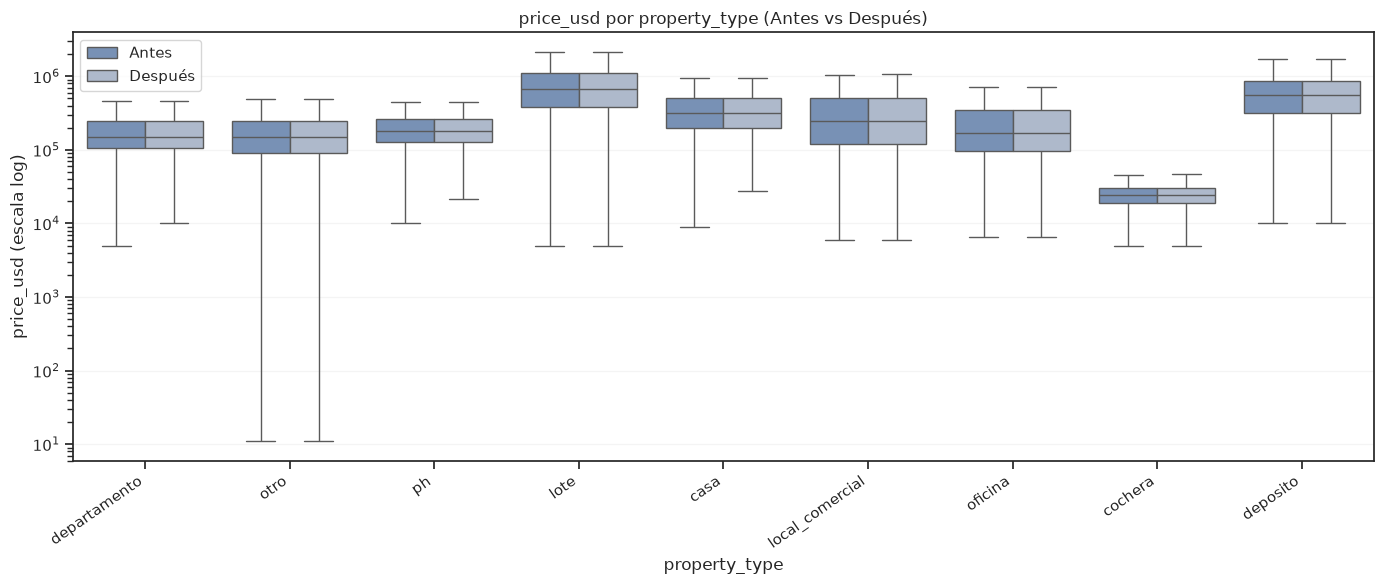

In [196]:
# Boxplot compuesto: Antes vs Después en price_usd por property_type

col_antes = "price_usd_original" if "price_usd_original" in df.columns else "price_usd"

if "price_usd_target" in df.columns:
    col_despues = "price_usd_target"
elif "price_usd_treated" in df.columns:
    col_despues = "price_usd_treated"
elif "price_usd_cap" in df.columns:
    col_despues = "price_usd_cap"
else:
    col_despues = "price_usd"

tmp = df[["property_type", col_antes, col_despues]].copy()
tmp[col_antes] = pd.to_numeric(tmp[col_antes], errors="coerce")
tmp[col_despues] = pd.to_numeric(tmp[col_despues], errors="coerce")
tmp = tmp[(tmp[col_antes] > 0) & (tmp[col_despues] > 0)]

# filtra tipos con muy pocos casos para mejorar legibilidad
types_ok = tmp["property_type"].value_counts()
types_ok = types_ok[types_ok >= 30].index
tmp = tmp[tmp["property_type"].isin(types_ok)]

plot_df = tmp.melt(
    id_vars="property_type",
    value_vars=[col_antes, col_despues],
    var_name="momento",
    value_name="price_usd"
)

plot_df["momento"] = plot_df["momento"].map({
    col_antes: "Antes",
    col_despues: "Después"
})

order = tmp["property_type"].value_counts().index

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=plot_df,
    x="property_type",
    y="price_usd",
    hue="momento",
    order=order,
    showfliers=False
)
plt.yscale("log")
plt.title("price_usd por property_type (Antes vs Después)")
plt.xlabel("property_type")
plt.ylabel("price_usd (escala log)")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.2)
plt.legend(title="")
plt.tight_layout()
plt.show()

#### Encoding de nuevas variables

Se generaron nuevas variables booleanas a partir del minado textual de título y descripción unificados. 

Para eso, creamos un diccionario de atributos de vivienda (por ejemplo, balcón, terraza, cochera, amenities o cercanía al subte), que se buscaron con regex en los campos textuales no estructurados del aviso. 

In [167]:
# Atributos de vivienda a partir de text_mining
# (text_mining ya viene de title_mining + description_mining)

columnas_dict = {
    "estrenar": "estrenar",
    "impecable": "impecable",
    "lujoso": "lujoso",
    "luminoso": "luminoso",
    "apto_credito": ["apto credito", "apto-credito", "credito hipotecario", "crédito hipotecario"],
    "balcon": "balcon",
    "terraza": "terraza",
    "patio": "patio",
    "jardin": "jardin",
    "piscina": "piscina",
    "parrilla": "parrilla",
    "quincho": "quincho",
    "toilette": "toilette",
    "lavadero": "lavadero",
    "dependencias": "dependencias",
    "suite": "suite",
    "vestidor": "vestidor",
    "sauna": "sauna",
    "hidromasaje": "hidromasaje",
    "climatizado": ["aire acondicionado", "aire-acondicionado", "losa radiante", "losa-radiante"],
    "amenities": ["sum", "gimnasio", "amenities"],
    "baulera": "baulera",
    "cochera": ["garage", "cochera"],
    "subte_cerca": ["subte", "subte linea a", "subte linea b", "subte linea c", "subte linea d", "subte linea e", "subte linea h"]
}

# Serie base de texto
s_text = df["text_mining"].fillna("").astype(str).str.lower()

# Crear columnas booleanas desde text_mining
for k, v in columnas_dict.items():
    if isinstance(v, list):
        patron = "|".join(re.escape(x) for x in v)
        df[k] = s_text.str.contains(patron, regex=True, na=False)
    else:
        df[k] = s_text.str.contains(re.escape(v), regex=True, na=False)

# Chequeo rápido
atributos_column_names = list(columnas_dict.keys())
df[atributos_column_names].head()

,estrenar,impecable,lujoso,luminoso,apto_credito,balcon,terraza,patio,jardin,piscina,...,dependencias,suite,vestidor,sauna,hidromasaje,climatizado,amenities,baulera,cochera,subte_cerca
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,True,True,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,True,False,False,True


/tmp/ipykernel_169374/2450850975.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="")


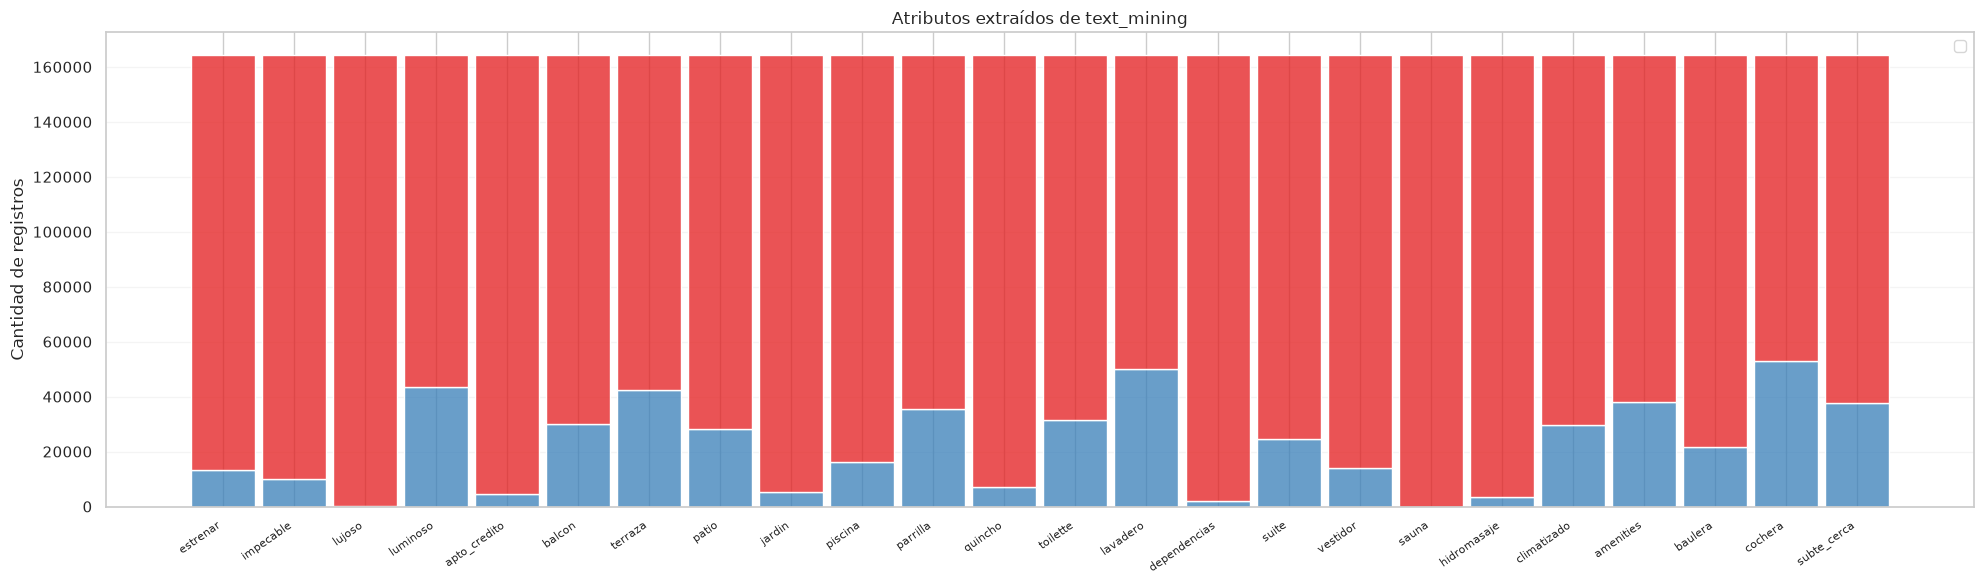

In [200]:
# 1) Nos quedamos solo con las columnas booleanas de atributos (las del diccionario)
vars_bools = df[atributos_column_names].copy()

# 2) Pasamos a formato largo
vars_bools_long = vars_bools.melt(var_name="atributo", value_name="presente")

# 3) Histplot apilado True/False por atributo
plt.figure(figsize=(20, 6))
sns.set_style("whitegrid")
sns.histplot(
    data=vars_bools_long,
    x="atributo",
    hue="presente",
    discrete=True,
    multiple="stack",
    palette="Set1",
    shrink=0.9
)

plt.title("Atributos extraídos de text_mining")
plt.xticks(fontsize=8, rotation=35, ha="right")
plt.ylabel("Cantidad de registros")
plt.xlabel("")
plt.tight_layout()
plt.grid(axis="y", alpha=0.2)
plt.legend(title="")
plt.tight_layout()
plt.show()


#### Pulido de variables existentes

##### Descarte de variables

Vamos a descartar la volumna l6, por no contener información relevante. 

In [ ]:
# Eliminamos columna 'l6', sin datos
df.drop(columns=["l6"], inplace=True)

# Eliminamos la columna 'operation_type', ya que todos los valores son iguales
df.drop(columns=['operation_type'], inplace=True)

# vamos a eliminar price_period, que es una varible asociada al subsets de avisos de alquileres

### Visualización de los datos

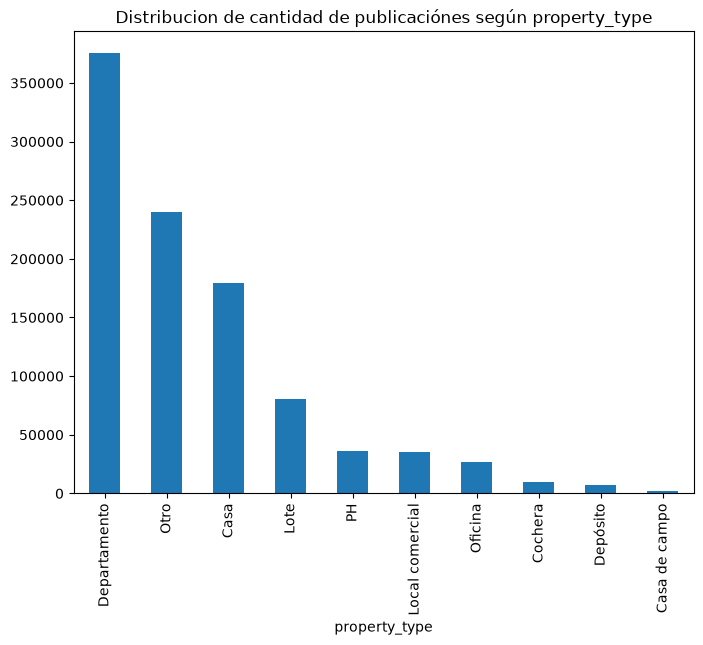

In [90]:
plt.figure(figsize=(8, 6))
df['property_type'].value_counts().plot(kind='bar')
plt.title('Distribucion de cantidad de publicaciónes según property_type')
plt.ylabel('')
plt.show()

Filas usadas en visualización: 161168


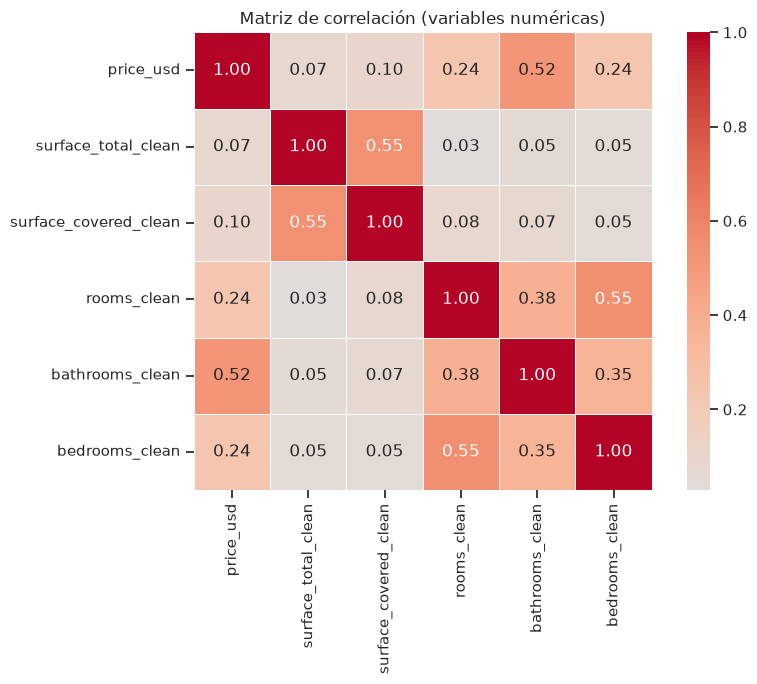

In [162]:
# =========================
# Variables numéricas para visualización
# =========================
cols_base = [
    "price_usd",
    "surface_total_clean",
    "surface_covered_clean",
    "rooms_clean",
    "bathrooms_clean",
    "bedrooms_clean",
]

cols_base = [c for c in cols_base if c in df.columns]

viz = df[cols_base].apply(pd.to_numeric, errors="coerce")
viz = viz.replace([np.inf, -np.inf], np.nan)

# Filtros mínimos para poder usar escala log en Y
viz = viz[
    viz["price_usd"].notna() &
    (viz["price_usd"] > 0)
].copy()

# Opcional: recorte visual de extremos para mejorar lectura
p_low = viz["price_usd"].quantile(0.01)
p_high = viz["price_usd"].quantile(0.99)
viz = viz[(viz["price_usd"] >= p_low) & (viz["price_usd"] <= p_high)].copy()

print("Filas usadas en visualización:", len(viz))

# =========================
# Heatmap de correlaciones
# =========================
corr_cols = ["price_usd"] + [c for c in cols_base if c != "price_usd"]
CORR = viz[corr_cols].corr()
correlacion = CORR.copy()

plt.figure(figsize=(9, 7))
sns.heatmap(
    CORR,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("Matriz de correlación (variables numéricas)")
plt.tight_layout()
plt.show()



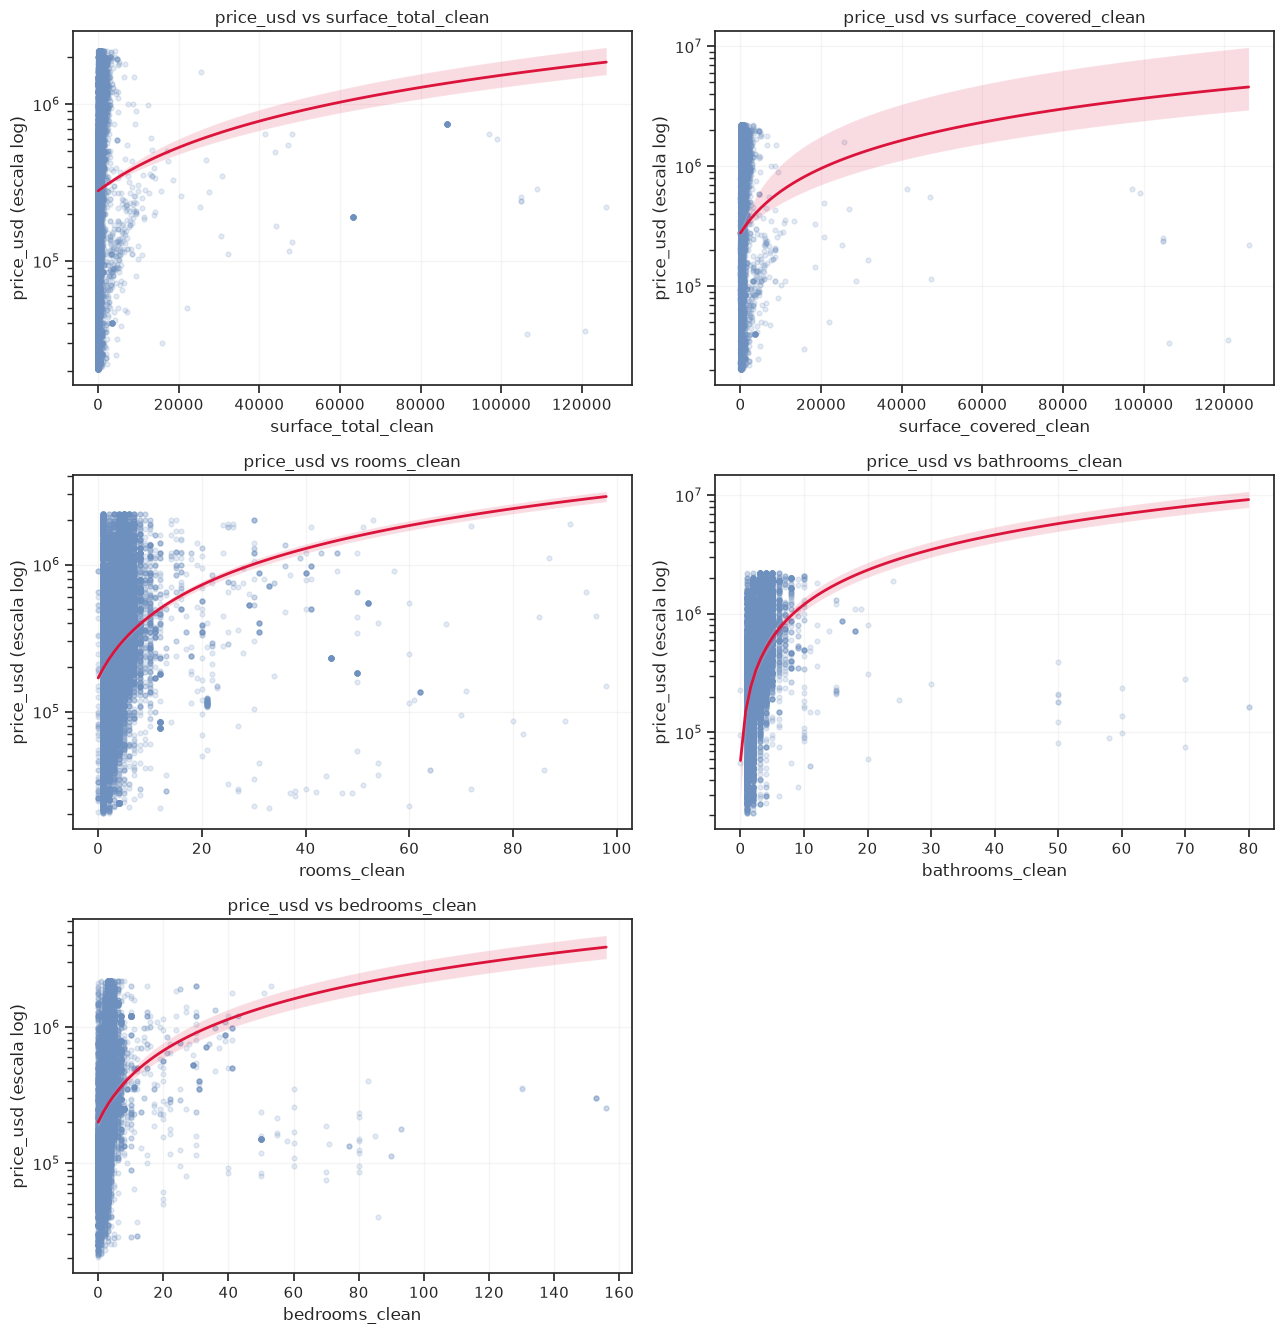

In [163]:

# =========================
# Regplots con eje Y en log
# =========================
features = [c for c in corr_cols if c != "price_usd"]

n = len(features)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(13, 4.5 * nrows))
axes = np.array(axes).reshape(-1)

for i, f in enumerate(features):
    tmp = viz[[f, "price_usd"]].dropna()
    tmp = tmp[tmp[f] > 0] if "surface" in f else tmp

    sns.regplot(
        data=tmp,
        x=f,
        y="price_usd",
        ax=axes[i],
        scatter_kws={"alpha": 0.18, "s": 12},
        line_kws={"color": "crimson", "linewidth": 2}
    )

    axes[i].set_yscale("log")
    axes[i].set_title("price_usd vs " + f)
    axes[i].set_ylabel("price_usd (escala log)")
    axes[i].grid(alpha=0.2)

# Oculta ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Descripción de los dataset

Resumí qué pudiste descubrir sobre el dataset a partir de los puntos anteriores.
Definí también, en esta sección, qué métrica(s) vas a usar para evaluar el
desempeño de los modelos (por ejemplo, MAE) y justificá por qué son
adecuadas para este problema de regresión en particular.

## Parte 2: Generación y Evaluación de Modelos

### Modelos

Dividí el conjunto de datos en entrenamiento/prueba y posteriormente entrená
al menos un modelo de Regresión Lineal y otro de Random Forest. Para este
último documentá y justificá los hiperparámetros elegidos

### Búsqueda de hiperparámetros

Utilizá GridSearchCV (u otra técnica de búsqueda de hiperparámetros) sobre
Random Forest. Compará el rendimiento del mejor modelo encontrado contra
la versión sin ajustar.

### Conclusiones

Resumí qué modelo recomendarías para este problema y por qué.
